In [1]:
# Imports, plotting configuration, and run-wide constants
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from networks import load_arm
from modelling import (
    load_vix, split_train_test, cluster_kmeans, cluster_hmm, fit_regime_order, validate_regime, empirical_transitions,
)
from spectral import SPECTRAL_FEATURE_COLUMNS, window_spectral, fit_spectral_embed, transform_spectral_embed
from plot_style import (
    set_publication_style, style_axis, shade_periods, format_date_axis, mark_split, annotate_events,
    REGIME_PALETTE, CRISIS_EVENTS, EPOCH_LENGTH_COLOURS,
)

set_publication_style()

k = 3
INDEX_CODE = "SP500"
ARM = "raw"
EPOCH_LENGTH = 132
TRAIN_TEST_CUTOFF = "2019-12-31"
REGIME_NAMES = ["Calm", "Transitional", "Crisis"]

In [2]:
# Load the raw arm's correlation matrices for S&P 500, split train/test, and the VIX series
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_corrs, test_corrs = train["correlation_matrices"], test["correlation_matrices"]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
vix = load_vix()
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 465, test windows: 164


In [3]:
# Step 1 -- singularity check: N, T, q, mp_edge, and structural zero count, printed before any clustering
window_stats = pd.DataFrame([window_spectral(C, stock_names, EPOCH_LENGTH) for C in train_corrs + test_corrs])
window_stats.index = pd.DatetimeIndex(pd.to_datetime(list(train_dates) + list(test_dates)))
window_stats.index.name = "epoch_date"

N = len(stock_names)
n_zero_eigenvalues = int(window_stats["n_zero_eigenvalues"].iloc[0])
q = float(window_stats["q"].iloc[0])
mp_edge = float(window_stats["mp_edge"].iloc[0])
print(f"N={N}  T={EPOCH_LENGTH}  q={q:.3f}  mp_edge={mp_edge:.2f}  n_zero_eigenvalues={n_zero_eigenvalues}")

N=349  T=132  q=0.378  mp_edge=6.90  n_zero_eigenvalues=218


In [4]:
# Step 1 summary -- mean market-mode and bulk statistics across all windows
summary_table = pd.DataFrame([{
    "epoch_length": EPOCH_LENGTH,
    "n_zero_eigenvalues": n_zero_eigenvalues,
    "q": q,
    "mp_edge": mp_edge,
    "mean_mu": window_stats["mu"].mean(),
    "mean_n_above_mp": window_stats["n_above_mp"].mean(),
    "mean_spectral_entropy_bulk": window_stats["spectral_entropy_bulk"].mean(),
}])
summary_table

,epoch_length,n_zero_eigenvalues,q,mp_edge,mean_mu,mean_n_above_mp,mean_spectral_entropy_bulk
0,132,218,0.378223,6.895978,0.323074,4.739269,0.927446


In [5]:
# Embed the windows: spectral/RMT feature table -> StandardScaler -> PCA(0.95), fit on train, transform both
X_raw = window_stats[SPECTRAL_FEATURE_COLUMNS].to_numpy()
X_train_raw, X_test_raw = X_raw[:n_train_windows], X_raw[n_train_windows:]

X_train, scaler, pca, fit_diag = fit_spectral_embed(X_train_raw)
X_test = transform_spectral_embed(X_test_raw, scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")

PCA-reduced embedding: train 465 x 6, test 164 x 6
Retained PCA dimensions: 6


In [6]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order = order

Mean μ per regime (train): {0: np.float64(0.316), 1: np.float64(0.26), 2: np.float64(0.563)}
Crisis regime: 2


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


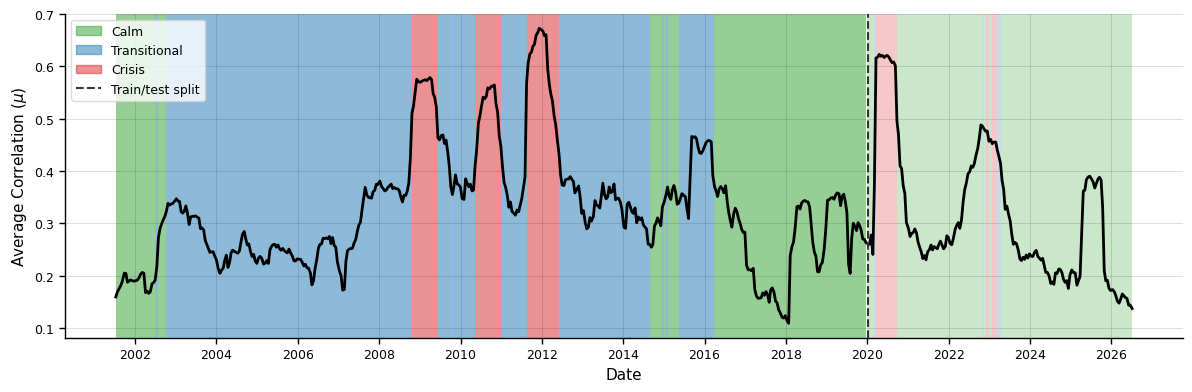

In [7]:
# Regime timeline shaded by mu-rank (K-means) -- train and test on one continuous axis
def plot_regime_timeline(train_dates, train_mu, train_labels, test_dates, test_mu, test_labels, rank_of_cluster):
    fig, ax = plt.subplots(figsize=(12, 4))

    def shade(dates, labels, alpha):
        for r in range(k):
            intervals = [(dates[i], dates[min(i + 1, len(dates) - 1)])
                         for i, lbl in enumerate(labels) if rank_of_cluster[lbl] == r]
            shade_periods(ax, intervals, REGIME_PALETTE[r], alpha=alpha)

    shade(train_dates, train_labels, alpha=0.5)
    shade(test_dates, test_labels, alpha=0.25)

    ax.plot(train_dates, train_mu, color="black", linewidth=2)
    ax.plot(test_dates, test_mu, color="black", linewidth=2)

    handles = [Patch(color=REGIME_PALETTE[r], alpha=0.5, label=REGIME_NAMES[r]) for r in range(k)]
    if len(test_dates) > 0:
        handles.append(mark_split(ax, test_dates[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel(r"Average Correlation ($\mu$)")
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray")
    plt.tight_layout()
    plt.show()

plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [8]:
# VIX validation F1 (K-means) -- train and test separately
res_train = validate_regime(km_train_labels, train_dates, vix, 30.0, crisis_id)
res_test = validate_regime(km_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_test["point"]))

train  point-in-time  precision 0.462  recall 0.500  F1 0.480
test   point-in-time  precision 0.389  recall 0.438  F1 0.412


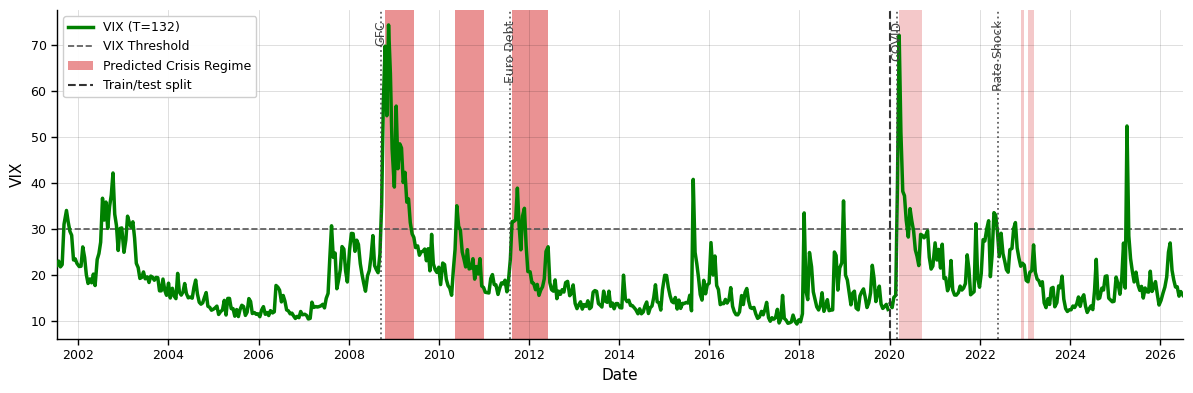

In [9]:
# VIX overlay with predicted-crisis shading, train and test on one continuous axis
def plot_vix_overlay(train_dates, res_train, test_dates, res_test):
    idx_train = pd.DatetimeIndex(pd.to_datetime(train_dates))
    idx_test = pd.DatetimeIndex(pd.to_datetime(test_dates))
    vix_color = EPOCH_LENGTH_COLOURS[EPOCH_LENGTH]
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(idx_train, res_train["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.plot(idx_test, res_test["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.axhline(30.0, color="#555555", linestyle="--", linewidth=1.2, zorder=2)

    def shade_crisis(idx, res, alpha):
        crisis_idx = np.where(res["pred"].astype(bool))[0]
        intervals = [(idx[i], idx[min(i + 1, len(idx) - 1)]) for i in crisis_idx]
        shade_periods(ax, intervals, REGIME_PALETTE[2], alpha=alpha)

    shade_crisis(idx_train, res_train, alpha=0.5)
    shade_crisis(idx_test, res_test, alpha=0.25)

    idx_all = idx_train.append(idx_test)
    annotate_events(ax, CRISIS_EVENTS, idx_all[0], idx_all[-1])

    handles = [Line2D([0], [0], color=vix_color, lw=2.5, label=f"VIX (T={EPOCH_LENGTH})"),
               Line2D([0], [0], color="#555555", lw=1.2, linestyle="--", label="VIX Threshold"),
               Patch(facecolor=REGIME_PALETTE[2], alpha=0.5, label="Predicted Crisis Regime")]
    if len(idx_test) > 0:
        handles.append(mark_split(ax, idx_test[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel("VIX")
    ax.set_xlim(idx_all[0], idx_all[-1])
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.95, edgecolor="#CCCCCC")
    plt.tight_layout()
    plt.show()

plot_vix_overlay(train_dates, res_train, test_dates, res_test)

In [10]:
# Fit best-of-20 HMM on train, predict both, mu-rank the regimes from train only
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean μ per regime (train): {0: np.float64(0.253), 1: np.float64(0.428), 2: np.float64(0.268)}
Crisis regime: 1


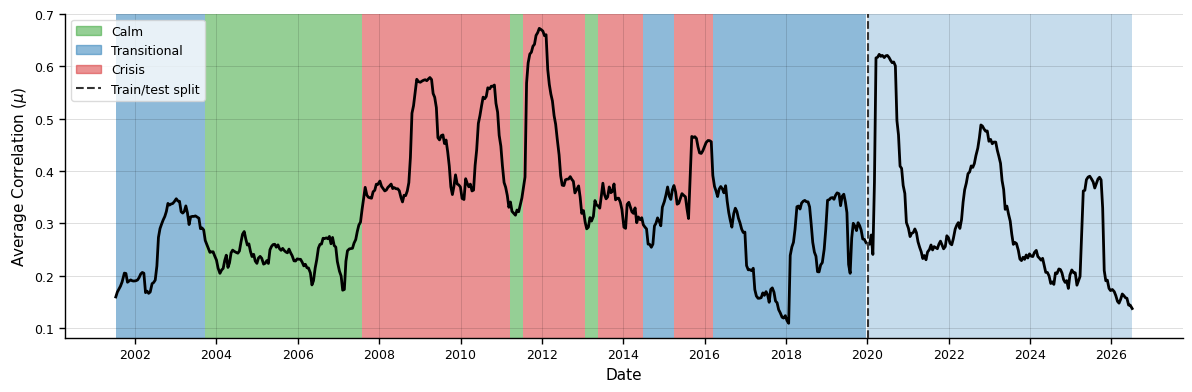

In [11]:
# Regime timeline shaded by mu-rank (HMM) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [12]:
# VIX validation F1 (HMM) -- train and test separately
res_hmm_train = validate_regime(hmm_train_labels, train_dates, vix, 30.0, crisis_id)
res_hmm_test = validate_regime(hmm_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_test["point"]))

train  point-in-time  precision 0.154  recall 0.583  F1 0.243
test   point-in-time  precision 0.000  recall 0.000  F1 0.000


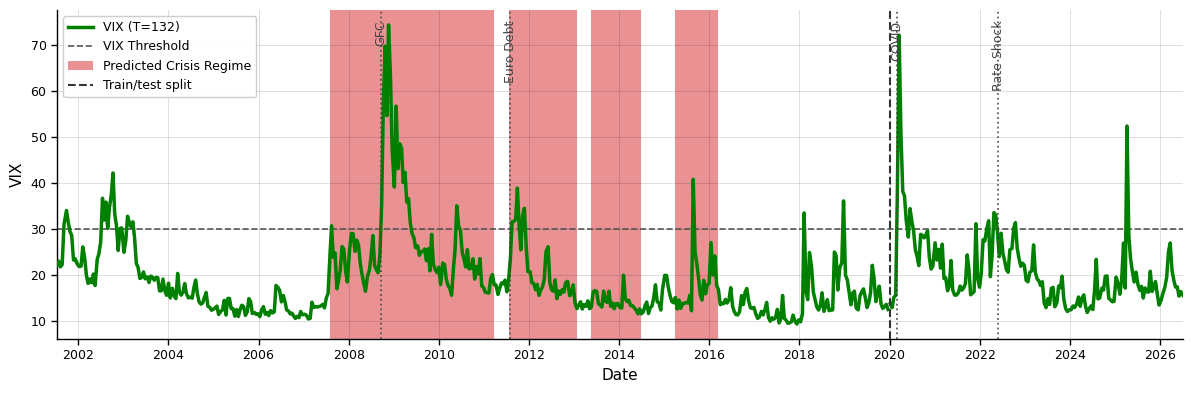

In [13]:
# VIX overlay with predicted-crisis shading (HMM), train and test on one continuous axis
plot_vix_overlay(train_dates, res_hmm_train, test_dates, res_hmm_test)

In [14]:
# Empirical train/test transition matrices for both clustering methods
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.957 0.043 0.   ]
 [0.022 0.967 0.011]
 [0.    0.058 0.942]] 
occupancy: [141 272  52]
K-means test transitions:
 [[0.971 0.021 0.007]
 [0.4   0.2   0.4  ]
 [0.111 0.056 0.833]] 
occupancy: [141   5  18]

HMM train transitions:
 [[0.973 0.    0.027]
 [0.006 0.988 0.006]
 [0.011 0.011 0.978]] 
occupancy: [113 170 182]
HMM test transitions:
 [[nan nan nan]
 [ 0.  1.  0.]
 [nan nan nan]] 
occupancy: [  0 164   0]


In [15]:
# Load the raw arm's correlation matrices for Nikkei 225 (no VIX-equivalent series, so no F1/VIX-overlay cells below)
INDEX_CODE = "Nikkei225"
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_corrs, test_corrs = train["correlation_matrices"], test["correlation_matrices"]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 453, test windows: 159


In [16]:
# Step 1 -- singularity check: N, T, q, mp_edge, and structural zero count, printed before any clustering (Nikkei 225)
window_stats = pd.DataFrame([window_spectral(C, stock_names, EPOCH_LENGTH) for C in train_corrs + test_corrs])
window_stats.index = pd.DatetimeIndex(pd.to_datetime(list(train_dates) + list(test_dates)))
window_stats.index.name = "epoch_date"

N = len(stock_names)
n_zero_eigenvalues = int(window_stats["n_zero_eigenvalues"].iloc[0])
q = float(window_stats["q"].iloc[0])
mp_edge = float(window_stats["mp_edge"].iloc[0])
print(f"N={N}  T={EPOCH_LENGTH}  q={q:.3f}  mp_edge={mp_edge:.2f}  n_zero_eigenvalues={n_zero_eigenvalues}")

N=177  T=132  q=0.746  mp_edge=4.66  n_zero_eigenvalues=46


In [17]:
# Step 1 summary -- mean market-mode and bulk statistics across all windows (Nikkei 225)
summary_table = pd.DataFrame([{
    "epoch_length": EPOCH_LENGTH,
    "n_zero_eigenvalues": n_zero_eigenvalues,
    "q": q,
    "mp_edge": mp_edge,
    "mean_mu": window_stats["mu"].mean(),
    "mean_n_above_mp": window_stats["n_above_mp"].mean(),
    "mean_spectral_entropy_bulk": window_stats["spectral_entropy_bulk"].mean(),
}])
summary_table

,epoch_length,n_zero_eigenvalues,q,mp_edge,mean_mu,mean_n_above_mp,mean_spectral_entropy_bulk
0,132,46,0.745763,4.656862,0.3857,2.928105,0.885376


In [18]:
# Embed the windows: spectral/RMT feature table -> StandardScaler -> PCA(0.95), fit on train, transform both (Nikkei 225)
X_raw = window_stats[SPECTRAL_FEATURE_COLUMNS].to_numpy()
X_train_raw, X_test_raw = X_raw[:n_train_windows], X_raw[n_train_windows:]

X_train, scaler, pca, fit_diag = fit_spectral_embed(X_train_raw)
X_test = transform_spectral_embed(X_test_raw, scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")

PCA-reduced embedding: train 453 x 6, test 159 x 6
Retained PCA dimensions: 6


In [19]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only (Nikkei 225)
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order = order

Mean μ per regime (train): {0: np.float64(0.5), 1: np.float64(0.375), 2: np.float64(0.328)}
Crisis regime: 0


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


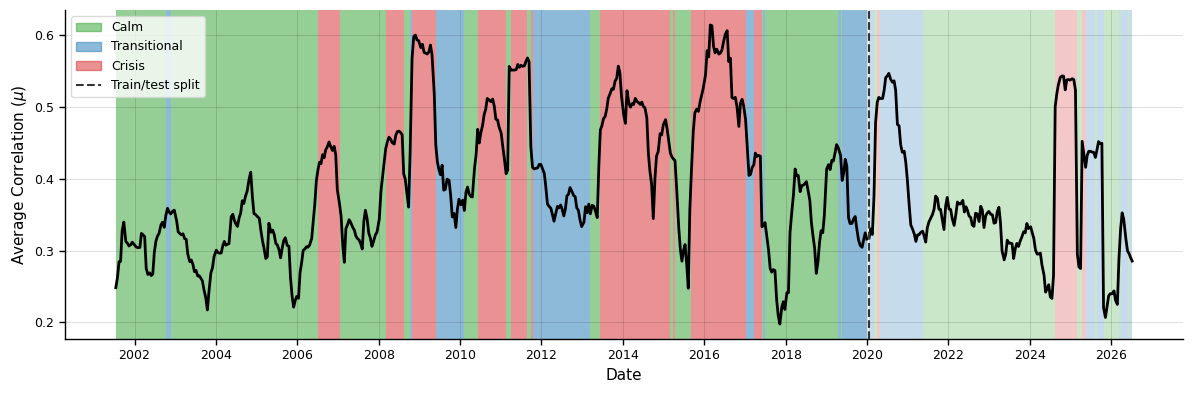

In [20]:
# Regime timeline shaded by mu-rank (K-means, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [21]:
# Fit best-of-20 HMM on train, predict both, mu-rank the regimes from train only (Nikkei 225)
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Mean μ per regime (train): {0: np.float64(0.377), 1: np.float64(0.341), 2: np.float64(0.501)}
Crisis regime: 2


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


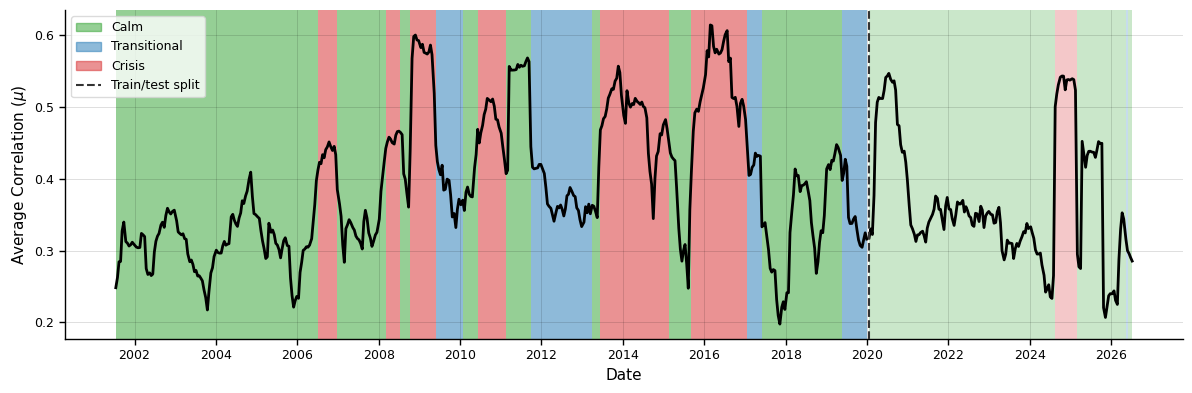

In [22]:
# Regime timeline shaded by mu-rank (HMM, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [23]:
# Empirical train/test transition matrices for both clustering methods (Nikkei 225)
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.943 0.022 0.035]
 [0.064 0.91  0.026]
 [0.048 0.021 0.932]] 
occupancy: [228  79 146]
K-means test transitions:
 [[0.928 0.041 0.031]
 [0.136 0.864 0.   ]
 [0.059 0.118 0.824]] 
occupancy: [97 45 17]

HMM train transitions:
 [[0.968 0.008 0.024]
 [0.039 0.961 0.   ]
 [0.031 0.016 0.953]] 
occupancy: [248  78 127]
HMM test transitions:
 [[0.986 0.007 0.007]
 [1.    0.    0.   ]
 [0.077 0.    0.923]] 
occupancy: [145   1  13]
